In [9]:
import pandas as pd

url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

red = pd.read_csv(url_red, sep=";")
white = pd.read_csv(url_white, sep=";")

Encode color variable to 0/1, the concat the datasets

In [10]:
red["color"] = 0
white["color"] = 1
wine = pd.concat([red, white], ignore_index=True)
wine = wine.sample(frac=1, random_state=1234).reset_index(drop=True)
wine.shape

(9796, 13)

In [11]:
X = wine.drop("quality", axis=1)
y = wine["quality"]
X.shape, y.shape

((9796, 12), (9796,))

In [12]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,color
0,6.1,0.22,0.40,1.85,0.031,25.0,111.0,0.98966,3.03,0.30,11.8,1
1,7.2,0.39,0.62,11.00,0.047,66.0,178.0,0.99760,3.16,0.50,8.7,1
2,6.4,0.31,0.28,1.50,0.037,12.0,119.0,0.99190,3.32,0.51,10.4,1
3,7.8,0.32,0.31,1.70,0.036,46.0,195.0,0.99300,3.03,0.48,10.5,1
4,6.9,0.16,0.30,9.60,0.057,50.0,185.0,0.99780,3.39,0.38,9.6,0


In [13]:
from sklearn.model_selection import train_test_split

seed = 1234

# first split test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=seed,
    stratify=y,
)

# split train / validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=seed,
    stratify=y_train_full,
)

scale X

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# y stays same

<function print>

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
classifier = LogisticRegression(solver='lbfgs', fit_intercept=True, max_iter=1000)
classifier.fit(X_train_scaled, y_train)
test_pred = classifier.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)
train_pred = classifier.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)
print("acc of test: ", format(100*test_acc, '.2f') )
print("acc of train: ", format(100*train_acc, '.2f') )

Cs = [0.001, 0.01, 0.1, 1, 10, 100]

acc of test:  54.39
acc of train:  54.47
When C = 0.001 acc of test:  54.39
When C = 0.001 acc of train:  54.40
When C = 0.001 acc of val:  54.47
When C = 0.01 acc of test:  54.39
When C = 0.01 acc of train:  54.40
When C = 0.01 acc of val:  54.47
When C = 0.1 acc of test:  54.39
When C = 0.1 acc of train:  54.40
When C = 0.1 acc of val:  54.47
When C = 1 acc of test:  54.39
When C = 1 acc of train:  54.40
When C = 1 acc of val:  54.47
When C = 10 acc of test:  54.39
When C = 10 acc of train:  54.40
When C = 10 acc of val:  54.47
When C = 100 acc of test:  54.39
When C = 100 acc of train:  54.40
When C = 100 acc of val:  54.47


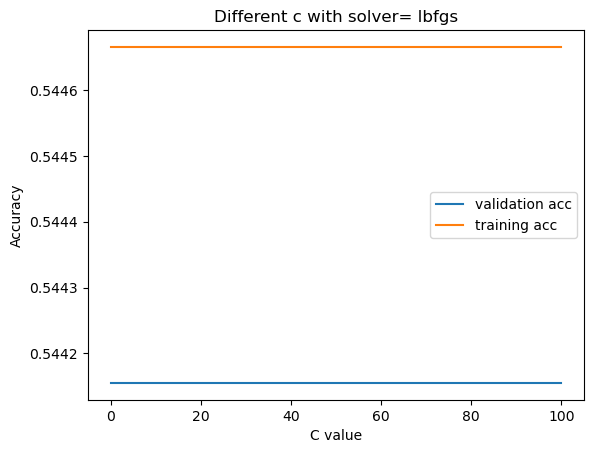

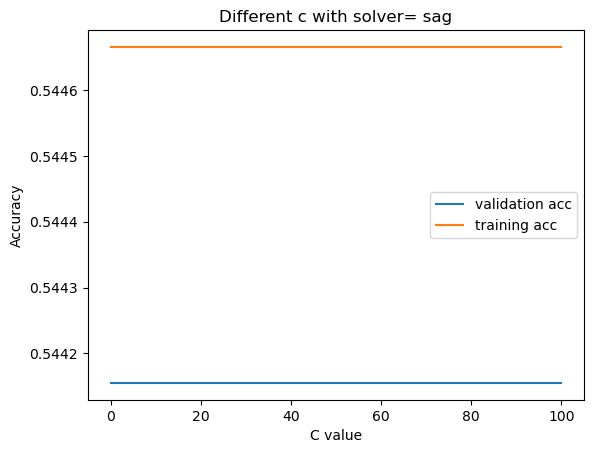

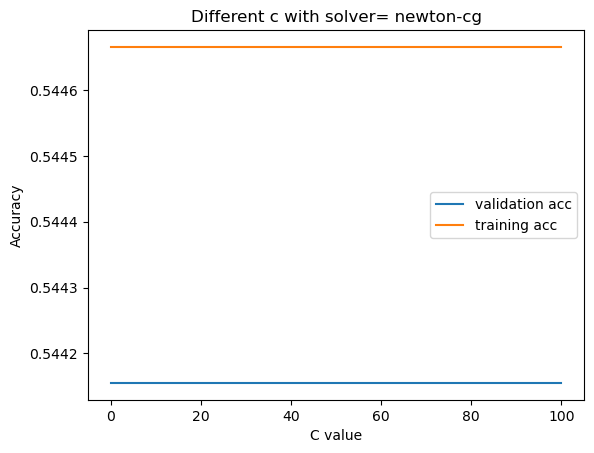

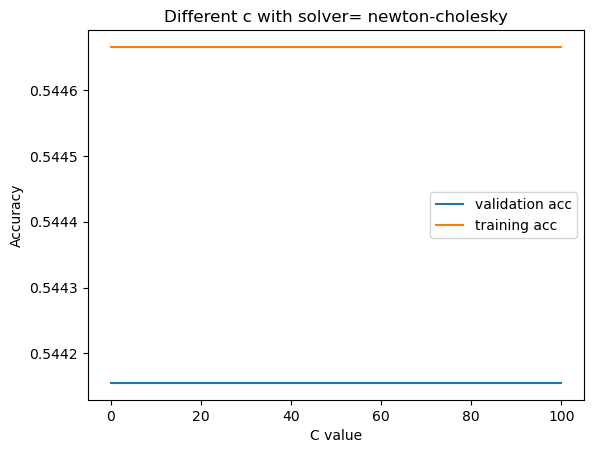

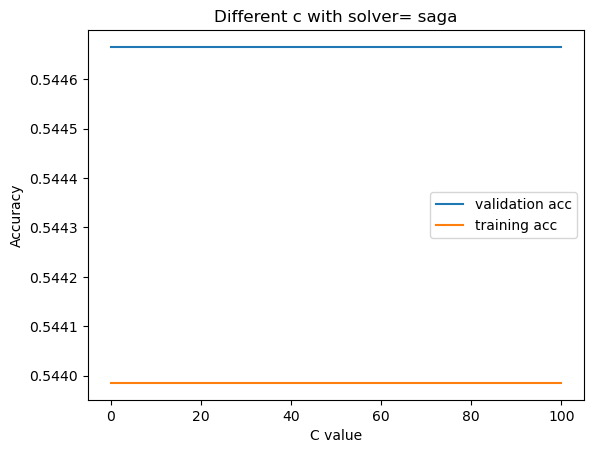

In [27]:
def plot_lr(sol, penal='l2', l1_r=0.0):
    plt.figure()
    plt.title("Different c with solver= " + sol)
    val_accs =[]
    train_accs = []
    test_accs = []
    for c in Cs:
        if(penal != 'l2'):
            classifier = LogisticRegression(solver=sol, penalty=penal, l1_ratio=l1_r, max_iter=1000)
        else:
            classifier = LogisticRegression(solver=sol, max_iter=1000)
        classifier.fit(X_train_scaled, y_train)
        test_pred = classifier.predict(X_test_scaled)
        test_acc = accuracy_score(y_test, test_pred)
        train_pred = classifier.predict(X_train_scaled)
        train_acc = accuracy_score(y_train, train_pred)
        train_pred = classifier.predict(X_train_scaled)
        train_acc = accuracy_score(y_train, train_pred)
        val_pred = classifier.predict(X_val_scaled)
        val_acc = accuracy_score(y_val, val_pred)
        val_accs.append(val_acc)
        train_accs.append(train_acc)
        # test_accs.append(test_acc)

        # print("When C =", c, "acc of test: ", format(100*test_acc, '.2f') )
        # print("When C =", c, "acc of train: ", format(100*train_acc, '.2f') )
        # print("When C =", c, "acc of val: ", format(100*val_acc, '.2f') )
    plt.plot(Cs, val_accs, label="validation acc")
    plt.plot(Cs, train_accs, label="training acc")
    plt.ylabel("Accuracy")
    plt.xlabel("C value")
    plt.legend()
    plt.show()

plot_lr("lbfgs")
plot_lr("sag")
plot_lr("newton-cg")
plot_lr("newton-cholesky")
plot_lr("saga",penal='elasticnet',l1_r=0.5)

For this part, it's obvious that tuning the model with different C or solver would not help with the original dataset.
So what about changing the dataset for logistic_regression?
Logistic_regression works best when the target is categorical, but the current dataset scales from 0-10. From now on 0-5 would be classified as bad(0), while 6-10 would be classified as good(1).


In [ ]:
# setup classified y
y_test_cls = (y_test >= 6).astype(int)
y_train_cls = (y_train >= 6).astype(int)
y_val_cls = (y_val >= 6).astype(int)
def plot_lr_cls(sol, penal='l2', l1_r=0.0):
    plt.figure()
    plt.title("Different c with solver= " + sol)
    val_accs =[]
    train_accs = []
    test_accs = []
    for c in Cs:
        if(penal != 'l2'):
            if(sol == 'liblinear'):
                classifier = LogisticRegression(solver=sol, penalty=penal,  max_iter=1000)
            else:
                classifier = LogisticRegression(solver=sol, penalty=penal, l1_ratio=l1_r, max_iter=1000)
        else:
            classifier = LogisticRegression(solver=sol, max_iter=1000)
        classifier.fit(X_train_scaled, y_train_cls)
        test_pred = classifier.predict(X_test_scaled)
        test_acc = accuracy_score(y_test_cls, test_pred)
        train_pred = classifier.predict(X_train_scaled)
        train_acc = accuracy_score(y_train_cls, train_pred)
        train_pred = classifier.predict(X_train_scaled)
        train_acc = accuracy_score(y_train_cls, train_pred)
        val_pred = classifier.predict(X_val_scaled)
        val_acc = accuracy_score(y_val_cls, val_pred)
        val_accs.append(val_acc)
        train_accs.append(train_acc)
        # test_accs.append(test_acc)

        # print("When C =", c, "acc of test: ", format(100*test_acc, '.2f') )
        # print("When C =", c, "acc of train: ", format(100*train_acc, '.2f') )
        # print("When C =", c, "acc of val: ", format(100*val_acc, '.2f') )
    plt.plot(Cs, val_accs, label="validation acc")
    plt.plot(Cs, train_accs, label="training acc")
    plt.ylabel("Accuracy")
    plt.xlabel("C value")
    plt.legend()
    plt.show()
plot_lr_cls('liblinear')
plot_lr_cls('lbfgs')
plot_lr_cls('liblinear', penal="l1", l1_r=)

IndentationError: expected an indented block after 'if' statement on line 13 (1285753441.py, line 14)

In [18]:
# now testing acc if red and white are tested separatedly
X_red = red.drop('quality', axis=1)
y_red = red["quality"]
# print(X_red[:10])
print(X_red.shape)
# print(y_red[:10])
print(y_red.shape)
X_white = white.drop('quality', axis=1)
y_white = white["quality"]
# print(X_white[:10])
print(X_white.shape)
# print(y_white[:10])
print(y_white.shape)

(4898, 12)
(4898,)
(4898, 12)
(4898,)


In [19]:
X_red_train_full, X_red_test, y_red_train_full, y_red_test = train_test_split(
    X_red,
    y_red,
    test_size=0.2,
    random_state=seed,
    stratify=y_red,
)

# split train / validation
X_red_train, X_red_val, y_red_train, y_red_val = train_test_split(
    X_red_train_full,
    y_red_train_full,
    test_size=0.25,
    random_state=seed,
    stratify=y_red_train_full,
)

scaler = StandardScaler()

X_red_train_scaled = scaler.fit_transform(X_red_train)
X_red_val_scaled = scaler.transform(X_red_val)
X_red_test_scaled = scaler.transform(X_red_test)
Cs = [0.001, 0.01, 0.1, 1, 10, 100]
for c in Cs:
    classifier = LogisticRegression(solver='lbfgs', fit_intercept=True, max_iter=1000)
    classifier.fit(X_red_train_scaled, y_red_train)
    test_pred = classifier.predict(X_red_test_scaled)
    test_acc = accuracy_score(y_red_test, test_pred)
    train_pred = classifier.predict(X_red_train_scaled)
    train_acc = accuracy_score(y_red_train, train_pred)
    train_pred = classifier.predict(X_red_train_scaled)
    train_acc = accuracy_score(y_red_train, train_pred)
    val_pred = classifier.predict(X_red_val_scaled)
    val_acc = accuracy_score(y_red_val, val_pred)
    print("When C =", c, "acc of test: ", format(100*test_acc, '.2f') )
    print("When C =", c, "acc of train: ", format(100*train_acc, '.2f') )
    print("When C =", c, "acc of val: ", format(100*val_acc, '.2f') )

When C = 0.001 acc of test:  52.76
When C = 0.001 acc of train:  54.32
When C = 0.001 acc of val:  53.98
When C = 0.01 acc of test:  52.76
When C = 0.01 acc of train:  54.32
When C = 0.01 acc of val:  53.98
When C = 0.1 acc of test:  52.76
When C = 0.1 acc of train:  54.32
When C = 0.1 acc of val:  53.98
When C = 1 acc of test:  52.76
When C = 1 acc of train:  54.32
When C = 1 acc of val:  53.98
When C = 10 acc of test:  52.76
When C = 10 acc of train:  54.32
When C = 10 acc of val:  53.98
When C = 100 acc of test:  52.76
When C = 100 acc of train:  54.32
When C = 100 acc of val:  53.98


In [20]:
# now white
X_white_train_full, X_white_test, y_white_train_full, y_white_test = train_test_split(
    X_white,
    y_white,
    test_size=0.2,
    random_state=seed,
    stratify=y_white,
)

# split train / validation
X_white_train, X_white_val, y_white_train, y_white_val = train_test_split(
    X_white_train_full,
    y_white_train_full,
    test_size=0.25,
    random_state=seed,
    stratify=y_white_train_full,
)

scaler = StandardScaler()

X_white_train_scaled = scaler.fit_transform(X_white_train)
X_white_val_scaled = scaler.transform(X_white_val)
X_white_test_scaled = scaler.transform(X_white_test)
Cs = [0.001, 0.01, 0.1, 1, 10, 100]
for c in Cs:
    classifier = LogisticRegression(solver='lbfgs', fit_intercept=True, max_iter=1000)
    classifier.fit(X_white_train_scaled, y_white_train)
    test_pred = classifier.predict(X_white_test_scaled)
    test_acc = accuracy_score(y_white_test, test_pred)
    train_pred = classifier.predict(X_white_train_scaled)
    train_acc = accuracy_score(y_white_train, train_pred)
    train_pred = classifier.predict(X_white_train_scaled)
    train_acc = accuracy_score(y_white_train, train_pred)
    val_pred = classifier.predict(X_white_val_scaled)
    val_acc = accuracy_score(y_white_val, val_pred)
    print("When C =", c, "acc of test: ", format(100*test_acc, '.2f') )
    print("When C =", c, "acc of train: ", format(100*train_acc, '.2f') )
    print("When C =", c, "acc of val: ", format(100*val_acc, '.2f') )

When C = 0.001 acc of test:  52.76
When C = 0.001 acc of train:  54.32
When C = 0.001 acc of val:  53.98
When C = 0.01 acc of test:  52.76
When C = 0.01 acc of train:  54.32
When C = 0.01 acc of val:  53.98
When C = 0.1 acc of test:  52.76
When C = 0.1 acc of train:  54.32
When C = 0.1 acc of val:  53.98
When C = 1 acc of test:  52.76
When C = 1 acc of train:  54.32
When C = 1 acc of val:  53.98
When C = 10 acc of test:  52.76
When C = 10 acc of train:  54.32
When C = 10 acc of val:  53.98
When C = 100 acc of test:  52.76
When C = 100 acc of train:  54.32
When C = 100 acc of val:  53.98
